# SESSION 03: GRAY-LEVEL TRANSFROMATION

- Ex3_1: Gray-Level Transfromation
- Ex3_2: Image Cropping
- Ex3_3: Image Zooming
- Ex3_4: Image Flipping
- Ex3_5: Rotating Image
- Ex3_6: Rotating an arbitrary angle
- Ex3_7: Image Twirling

In [22]:
# Load packages
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [23]:
# connect to GG Drive
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [24]:
# Create a path link to Session folder
PATH = '/content/drive/MyDrive/IVP/Session_03/'

# Font size for figures
FS = 12

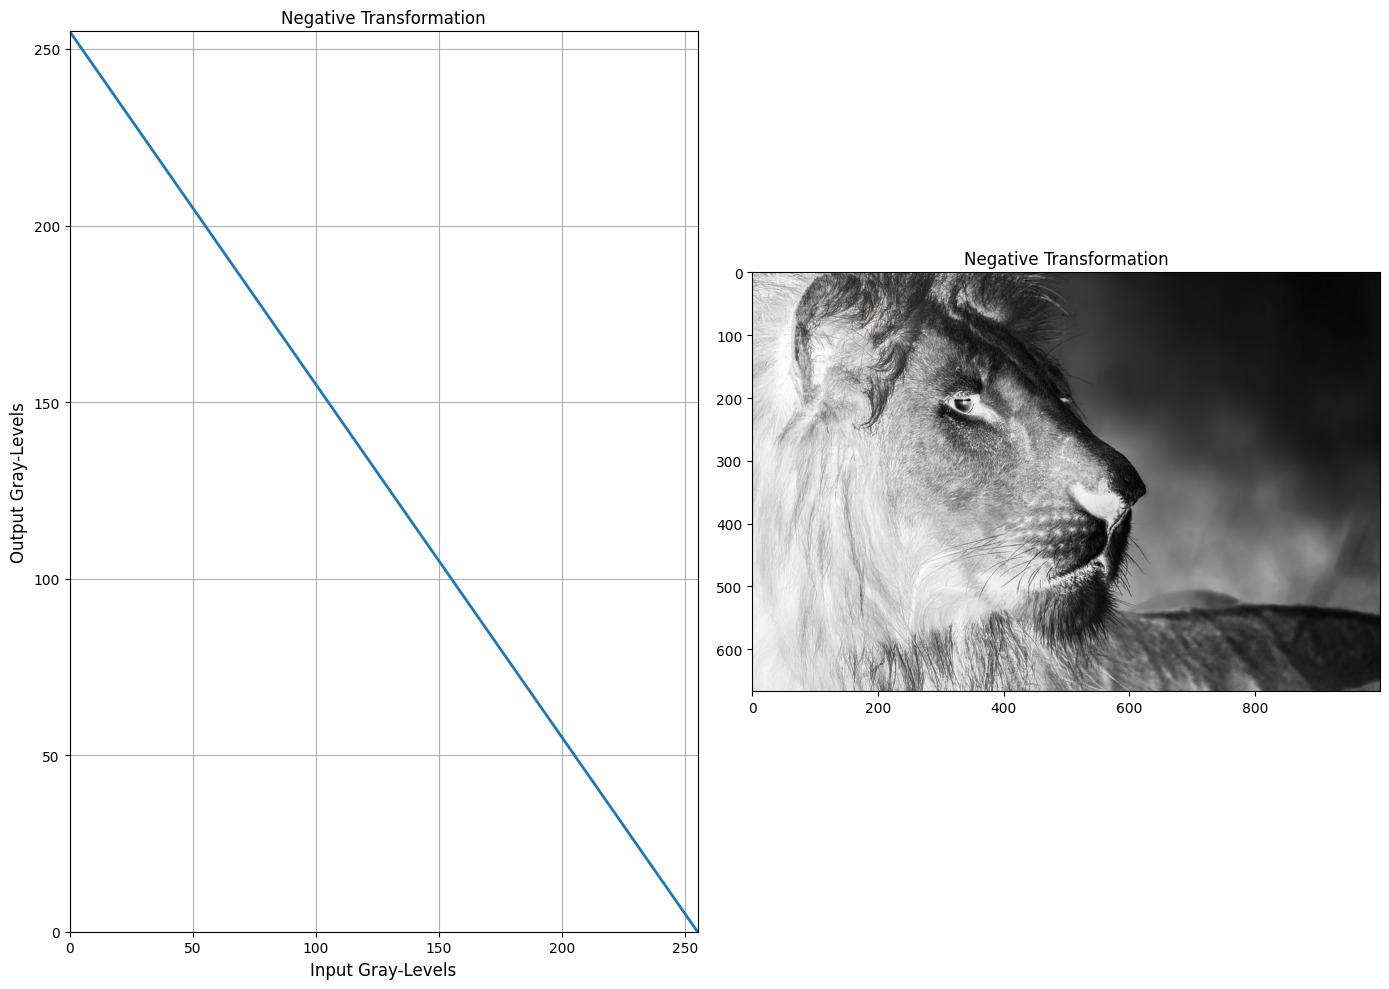

In [25]:
# Ex3_1: Gray-level Transformation

Img = cv2.imread(PATH + 'lion.jpg')
plt.figure(2, figsize=(14,10))

# a. Negative transformation
tf = np.arange(255, -1, -1, dtype=np.uint8) # Create a lookup table

# Plot transfromation function
plt.subplot(1, 2, 1), plt.plot(tf, linewidth=2.0)
plt.xlim([0, 255]), plt.ylim([0, 255]), plt.grid(True)
plt.xlabel('Input Gray-Levels', fontsize=FS), plt.ylabel('Output Gray-Levels', fontsize=FS)
plt.title('Negative Transformation', fontsize=FS)

# Apply the transformation on the input image
Img_a = cv2.LUT(Img, tf) # Apply the lookup table to every pixel in the image

# Display result
plt.subplot(1,2,2), plt.imshow(Img_a, cmap='gray'), plt.title('Negative Transformation', fontsize=FS)
plt.tight_layout()
plt.savefig(PATH + 'Ex3_1a.jpg', dpi=400)
plt.show()

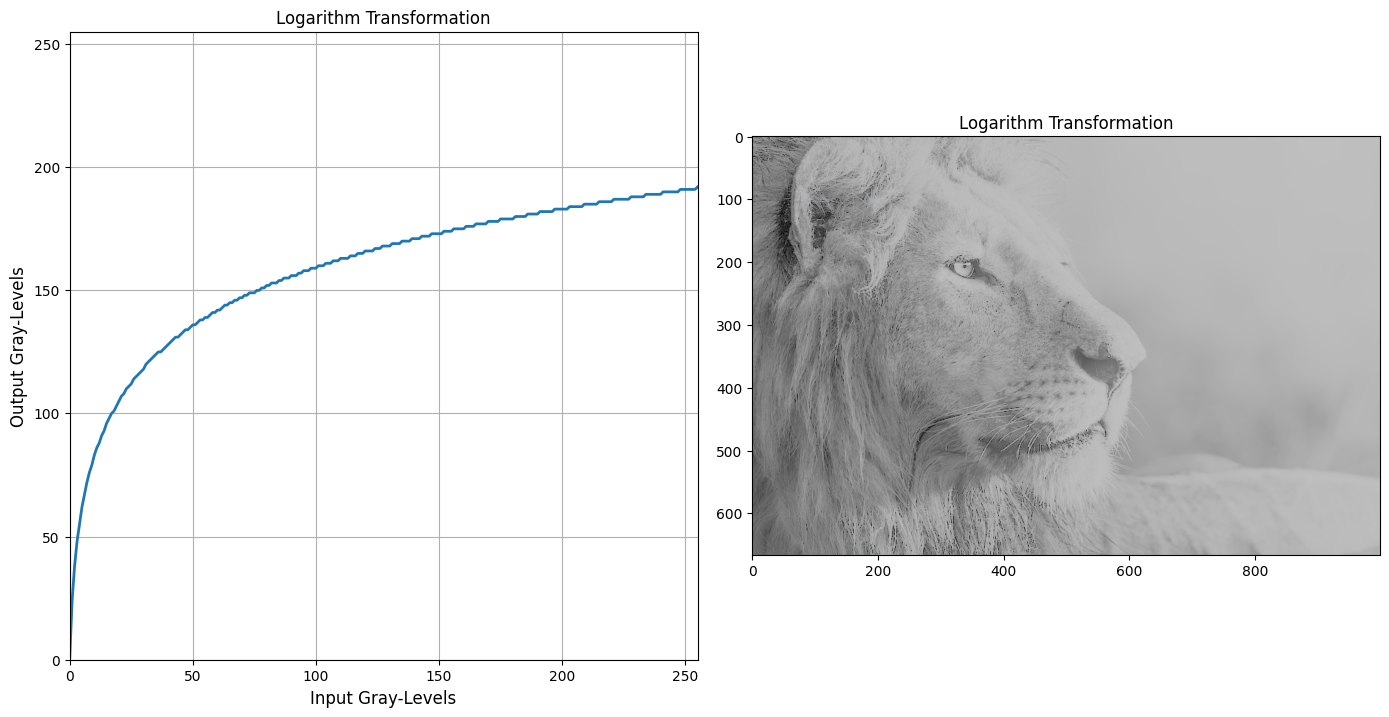

In [26]:
#b. Logarithm Transformation
plt.figure(2, figsize=(14,10))

# Transformation formula: s = c * log(1+r)
x = np.arange(0, 256, dtype=np.float64)
c = 192 / np.log(256)
tf = np.uint8(np.clip(c * np.log(x + 1), 0, 255)) # Create a lookup table

# Plot transfromation function
plt.subplot(1, 2, 1), plt.plot(x,tf, linewidth=2.0), plt.axis('square')
plt.xlim([0, 255]), plt.ylim([0, 255]), plt.grid(True)
plt.xlabel('Input Gray-Levels', fontsize=FS), plt.ylabel('Output Gray-Levels', fontsize=FS)
plt.title('Logarithm Transformation', fontsize=FS)

# Apply the transformation on the input image
Img_b = cv2.LUT(Img, tf)

plt.subplot(1,2,2), plt.imshow(Img_b, cmap='gray'), plt.title('Logarithm Transformation', fontsize=FS)
plt.tight_layout()
plt.savefig(PATH + 'Ex3_1b.jpg', dpi=400)
plt.show()

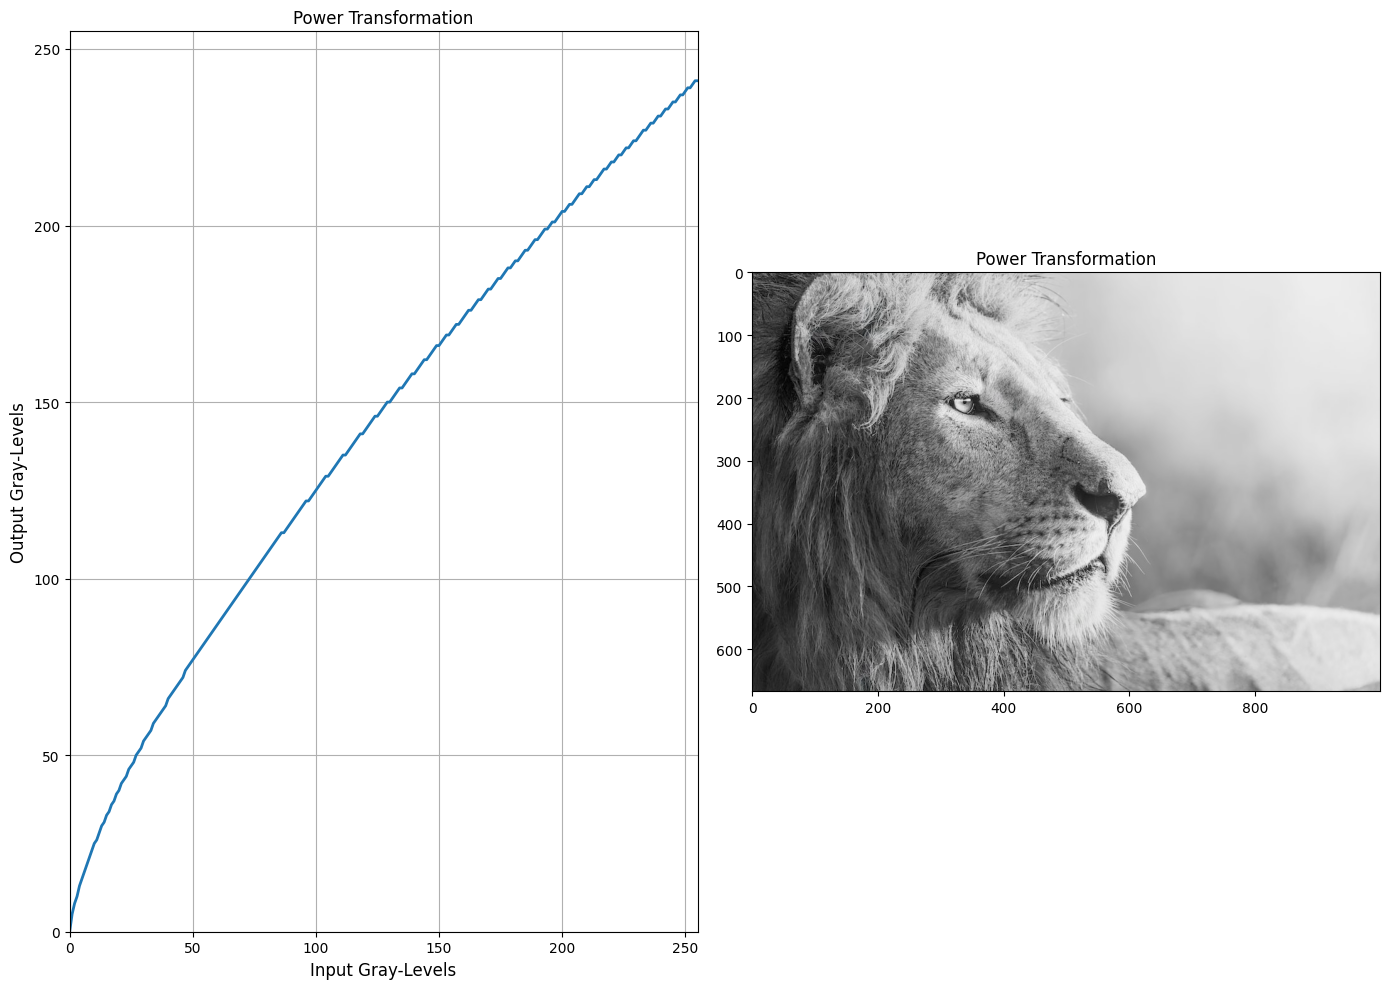

In [27]:
#c. Power Transformation
plt.figure(2, figsize=(14,10))

# Power-law (gamma) transformation: s = c * r^γ, where c=5 and γ=0.7
x = np.arange(0, 256, dtype=np.float64)
tf = np.uint8(np.clip(5 * np.power(x, 0.7), 0, 255))

# Plot transfromation function
plt.subplot(1, 2, 1), plt.plot(tf, linewidth=2.0)
plt.xlim([0, 255]), plt.ylim([0, 255]), plt.grid(True)
plt.xlabel('Input Gray-Levels', fontsize=FS), plt.ylabel('Output Gray-Levels', fontsize=FS)
plt.title('Power Transformation', fontsize=FS)

# Apply the transformation on the input image
Img_c = cv2.LUT(Img, tf)

plt.subplot(1,2,2), plt.imshow(Img_c, cmap='gray'), plt.title('Power Transformation', fontsize=FS)
plt.tight_layout()
plt.savefig(PATH + 'Ex3_1c.jpg', dpi=400)
plt.show()

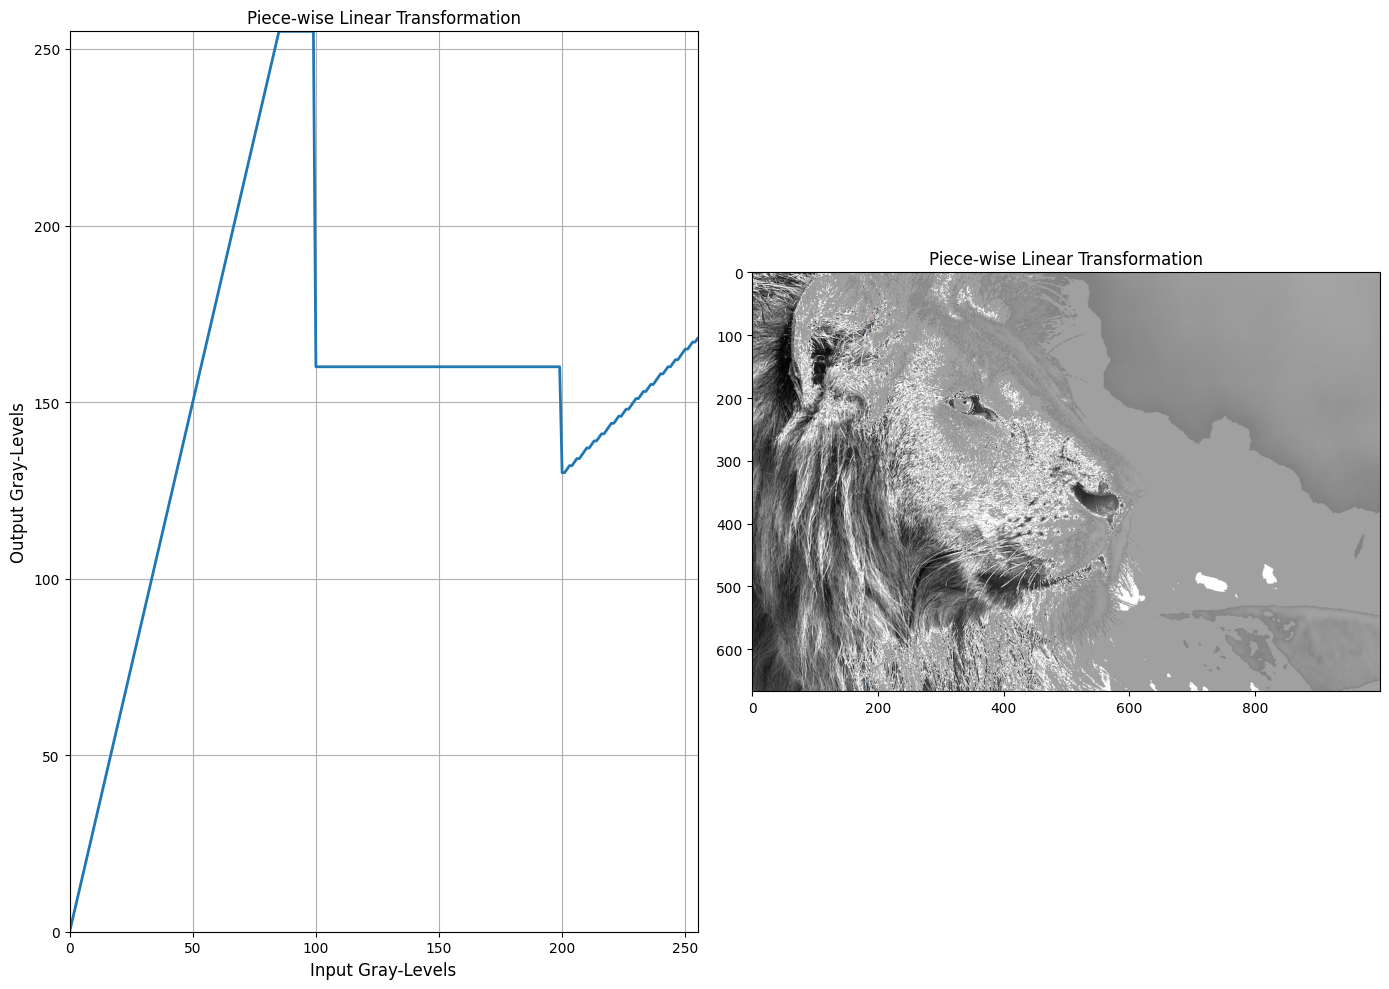

In [28]:
#d. Piece-wise Linear Transformation
plt.figure(2, figsize=(14,10))

# Create an empty lookup table with 256 gray-level entries initialized to zero.
tf = np.zeros(256, dtype=np.uint8)

# Map gray levels 0–99 using s = 3r
tf[0 : 100] = np.clip(3 * np.arange(0, 100), 0, 255)

# Map gray levels 100–199 to a constant intensity value of 160.
tf[100 : 200] = 160

# Map gray levels 200–255 using s = 0.7r - 10
tf[200 : 256] = np.clip(0.7 * np.arange(200, 256) - 10, 0, 255)


# Plot transfromation function
plt.subplot(1, 2, 1), plt.plot(tf, linewidth=2.0)
plt.xlim([0, 255]), plt.ylim([0, 255]), plt.grid(True)
plt.xlabel('Input Gray-Levels', fontsize=FS), plt.ylabel('Output Gray-Levels', fontsize=FS)
plt.title('Piece-wise Linear Transformation', fontsize=FS)

# Apply the transformation on the input image
Img_d = cv2.LUT(Img, tf)

plt.subplot(1,2,2), plt.imshow(Img_d, cmap='gray'), plt.title('Piece-wise Linear Transformation', fontsize=FS)
plt.tight_layout()
plt.savefig(PATH + 'Ex3_1d.jpg', dpi=400)
plt.show()

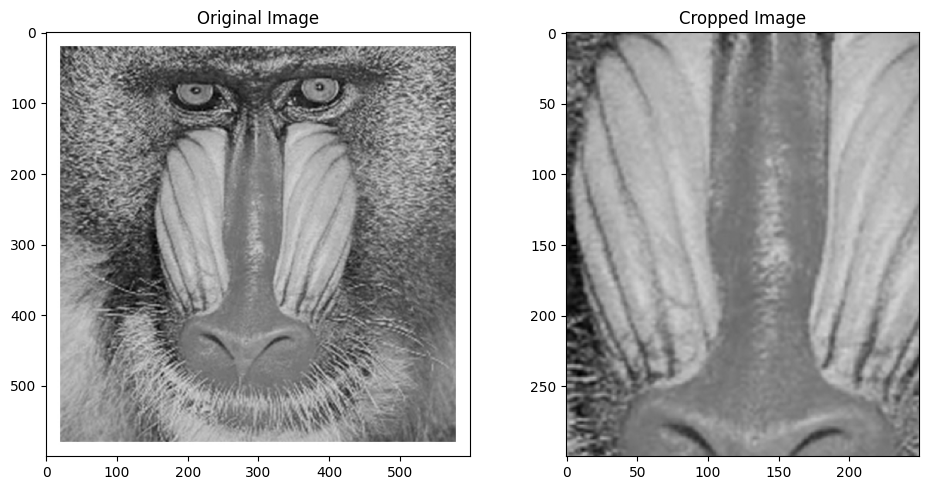

In [29]:
# Ex3_2: Cropping Image
Img = cv2.imread(PATH + 'mandrill.jpg')

# Define the crop regions (start and end coordinates)
# x1, x2: start - end column
# y1, y2: start - end row
x1, x2, y1, y2 = 150, 400, 150, 450

xmin, ymin = x1, y1 # Top-left coordinate of the crop rectangle
height, width = y2 - y1, x2 - x1  # Calculate the rectangle size

# Crop the image
Img_crop = Img[ymin: ymin + height, xmin: xmin + width]

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1), plt.imshow(cv2.cvtColor(Img, cv2.COLOR_BGR2RGB)), plt.title('Original Image', fontsize=FS)
plt.subplot(1, 2, 2), plt.imshow(cv2.cvtColor(Img_crop, cv2.COLOR_BGR2RGB)), plt.title('Cropped Image', fontsize=FS)
plt.tight_layout()
plt.show()

Original dimensions:  (667, 1000, 3)


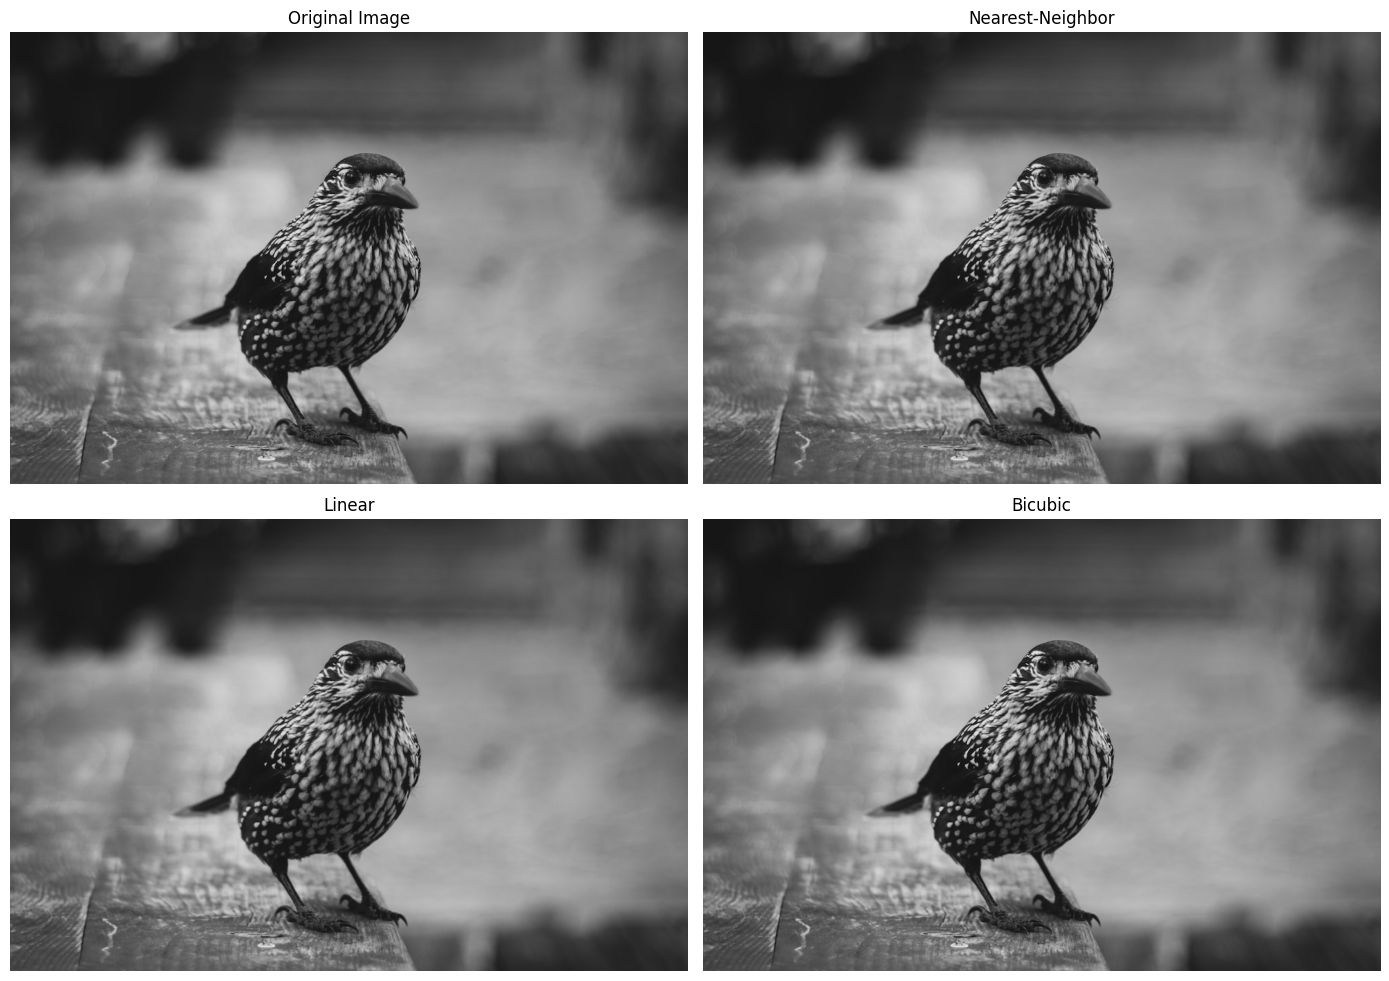

In [30]:
#Ex3_3: Image Zooming
Img = cv2.imread(PATH + 'bird.jpg', cv2.IMREAD_COLOR_RGB)

# check original dimensions
print('Original dimensions: ', Img.shape)

# Zoom with three diffenrent interpolation methods
Img_z1 = cv2.resize(Img, None, fx=4, fy=4, interpolation=cv2.INTER_NEAREST) #Nearest-Neighbor
Img_z2 = cv2.resize(Img, None, fx=3, fy=3, interpolation=cv2.INTER_LINEAR) #Linear
Img_z3 = cv2.resize(Img, None, fx=2, fy=2, interpolation=cv2.INTER_CUBIC) #Bicubic

#display results
plt.figure(figsize=(14, 10))

plt.subplot(2, 2, 1), plt.imshow(Img), plt.title('Original Image',fontsize=FS), plt.axis('off')
plt.subplot(2, 2, 2), plt.imshow(Img_z1), plt.title('Nearest-Neighbor',fontsize=FS), plt.axis('off')
plt.subplot(2, 2, 3), plt.imshow(Img_z2), plt.title('Linear',fontsize=FS), plt.axis('off')
plt.subplot(2, 2, 4), plt.imshow(Img_z3), plt.title('Bicubic',fontsize=FS), plt.axis('off')
plt.tight_layout()
plt.savefig(PATH + 'Ex3_3.jpg', dpi=400)
plt.show()


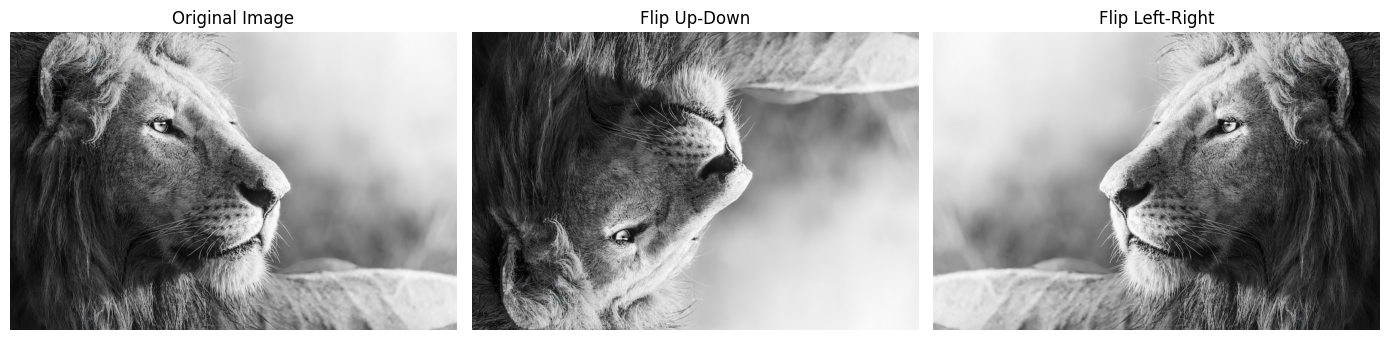

In [31]:
#Ex3_4: Image Flipping

Img = cv2.imread(PATH + 'lion.jpg')

# Flip the image up-down and left-right
Img_up = cv2.flip(Img, 0)
Img_lr = cv2.flip(Img, 1)

# Display results
plt.figure(figsize=(14,10))

plt.subplot(1, 3, 1), plt.imshow(Img), plt.title('Original Image',fontsize=FS), plt.axis('off')
plt.subplot(1, 3, 2), plt.imshow(Img_up), plt.title('Flip Up-Down',fontsize=FS), plt.axis('off')
plt.subplot(1, 3, 3), plt.imshow(Img_lr), plt.title('Flip Left-Right',fontsize=FS), plt.axis('off')
plt.tight_layout()
plt.savefig(PATH + 'Ex3_4.jpg', dpi=400)
plt.show()

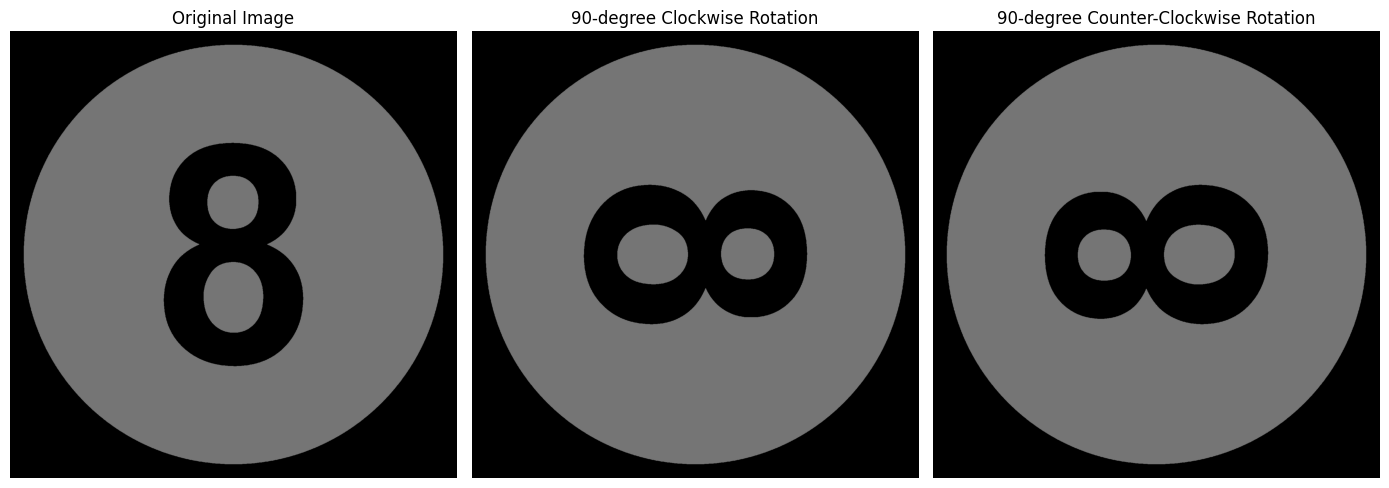

In [32]:
#Ex3_5:  Rotating Image
Img = cv2.imread(PATH + 'eight.png')

# Rotate with two different angles
Img_r1 = cv2.rotate(Img, cv2.ROTATE_90_CLOCKWISE) # Rotate the image 90 degrees in the clockwise direction.
Img_r2 = cv2.rotate(Img, cv2.ROTATE_90_COUNTERCLOCKWISE) # Rotate the image 90 degrees counterclockwise.

# Display results
plt.figure(figsize=(14, 10))

plt.subplot(2, 3, 1), plt.imshow(Img), plt.title('Original Image',fontsize=FS), plt.axis('off')
plt.subplot(2, 3, 2), plt.imshow(Img_r1), plt.title('90-degree Clockwise Rotation',fontsize=FS), plt.axis('off')
plt.subplot(2, 3, 3), plt.imshow(Img_r2), plt.title('90-degree Counter-Clockwise Rotation',fontsize=FS), plt.axis('off')
plt.tight_layout()
plt.savefig(PATH + 'Ex3_5.jpg', dpi=400)
plt.show()

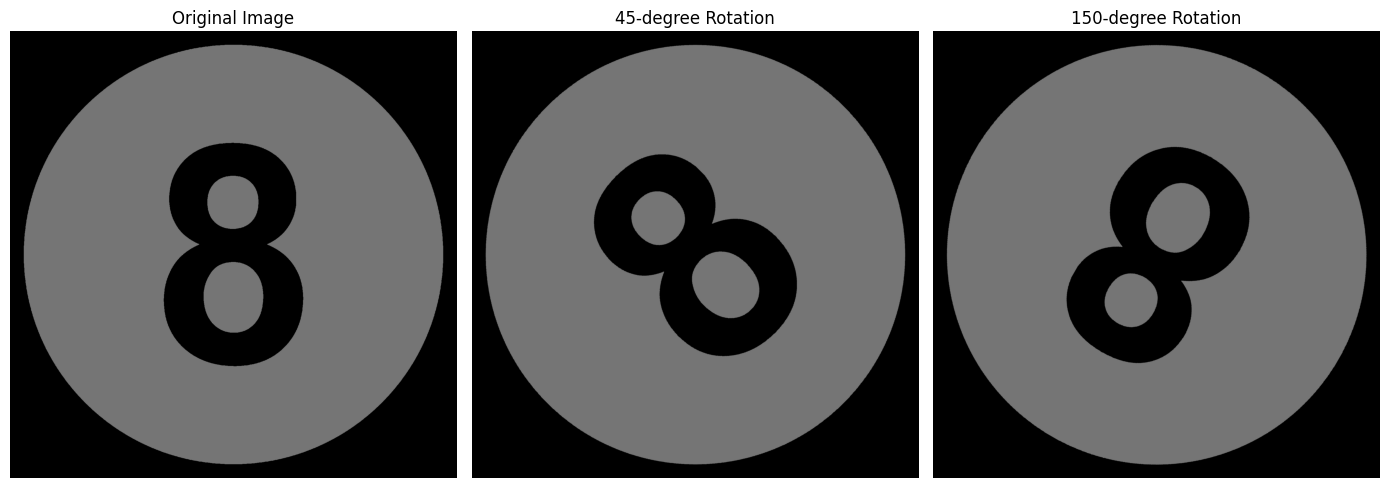

In [33]:
#Ex3_6: Rotating an arbitrary angle

def rotate_img(img, angle):
  h, w = img.shape[:2]
  center = (w/2, h/2)
  M = cv2.getRotationMatrix2D(center, angle, 1)
  return cv2.warpAffine(img, M, (w, h))

Img_r1 = rotate_img(Img, 45) # Rotate the image 45 degrees
Img_r2 = rotate_img(Img, 150) # Rotate the image 150 degrees

# Display results
plt.figure(figsize=(14, 10))

plt.subplot(2, 3, 1), plt.imshow(Img), plt.title('Original Image',fontsize=FS), plt.axis('off')
plt.subplot(2, 3, 2), plt.imshow(Img_r1), plt.title('45-degree Rotation',fontsize=FS), plt.axis('off')
plt.subplot(2, 3, 3), plt.imshow(Img_r2), plt.title('150-degree Rotation',fontsize=FS), plt.axis('off')
plt.tight_layout()
plt.savefig(PATH + 'Ex3_6.jpg', dpi=400)
plt.show()

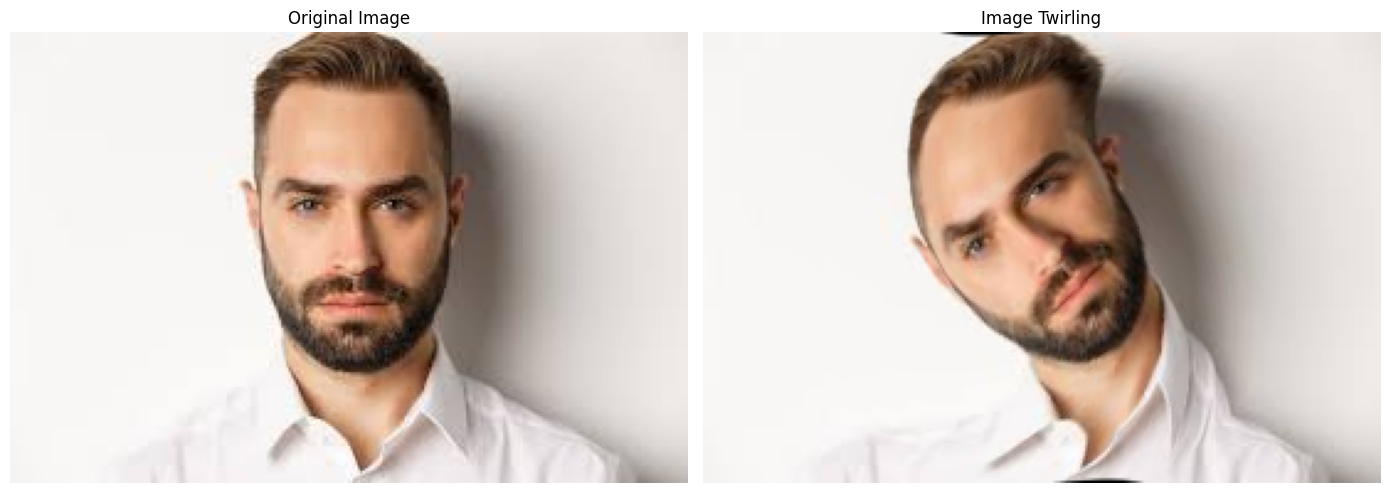

In [34]:
#Ex3_7: Image Twirling
Img = cv2.imread(PATH + 'man_face.jpg',cv2.IMREAD_COLOR_RGB)

def twirl_mg(img, strength=3.0, radius=None):
  h, w = img.shape[:2]   # Get the image height and width.
  cx, cy = w // 2, h //2 # Compute the center coordinates of the image.
  if radius is None:
    radius = min(h, w) // 2

  # Coordinate grid
  x, y = np.meshgrid(np.arange(w) - cx, np.arange(h) - cy)
  r = np.sqrt(x**2 + y**2) # Compute the distance of each pixel from the image center.
  theta = np.arctan2(y, x) # Compute the polar angle of each pixel relative to the image center.

  mask = r < radius        # Select pixels that lie within the twirl radius.
  r_norm = r[mask] / radius# Normalize distances to the range [0,1].
  theta[mask] += strength * (1-r_norm) # Increase the angle of pixels inside the radius to create the twirl effect.

  # Compute the new coordinates
  x_new = r * np.cos(theta) + cx
  y_new = r * np.sin(theta) + cy

  # Convert the coordinate maps to float32 format for remapping.
  map_x = x_new.astype(np.float32)
  map_y = y_new.astype(np.float32)

  return cv2.remap(img, map_x, map_y, cv2.INTER_LINEAR)

# Twirl the input image
# Apply the twirl effect with strength 1.0 within a radius of 100 pixels.
Img_twirled = twirl_mg(Img, strength=1.0, radius=100)

plt.figure(figsize=(14, 10))
plt.subplot(1, 2, 1), plt.imshow(Img), plt.title('Original Image',fontsize=FS), plt.axis('off')
plt.subplot(1, 2, 2), plt.imshow(Img_twirled), plt.title('Image Twirling',fontsize=FS), plt.axis('off')
plt.tight_layout()
plt.savefig(PATH + 'Ex3_7.jpg', dpi=400)
plt.show()